# Datavision EDA Summary

This notebook analyzes the datavision dataset for 2023-08-01 to 2025-01-31 (no raw table loading). It includes schema summary, missingness/zero rates, low variance checks, per-table prefix stats (using `FEATURE_TABLES`), label prevalence, and flagged feature candidates.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for path in candidates:
        dataset_path = path / "outputs" / "datavision_weekly_2023-08_2025-01.parquet"
        if dataset_path.exists():
            return path
        if (path / "src").exists() and (path / "outputs").exists():
            return path
    raise FileNotFoundError("Could not locate repo root with outputs/datavision_weekly_2023-08_2025-01.parquet")


root = find_repo_root(Path.cwd())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

dataset_path = root / "outputs" / "datavision_weekly_2023-08_2025-01.parquet"
df = pd.read_parquet(dataset_path)

try:
    from src.data.build_dataset import FEATURE_TABLES
except Exception:
    FEATURE_TABLES = [
        "adl_responses",
        "care_plans",
        "diagnoses",
        "document_tags",
        "factors",
        "gg_responses",
        "hospital_admissions",
        "hospital_transfers",
        "incidents",
        "injuries",
        "lab_reports",
        "medications",
        "physician_orders",
        "vitals",
    ]

df.shape

(64089, 204)

## Schema Summary

In [2]:
schema = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "nulls": df.isna().sum().values,
    }
)
schema["null_rate"] = (schema["nulls"] / len(df)).round(4)
schema.sort_values(["null_rate", "column"], ascending=[False, True]).head(30)

,column,dtype,non_null,nulls,null_rate
189,gait_assist_change_3,float64,0,64089,1.0000
72,adl_mean_30d,float64,1574,62515,0.9754
74,adl_slope_30d,float64,1574,62515,0.9754
73,adl_std_30d,float64,1574,62515,0.9754
76,adl_mean_90d,float64,1614,62475,0.9748
78,adl_slope_90d,float64,1614,62475,0.9748
77,adl_std_90d,float64,1614,62475,0.9748
71,adl_last,float64,1647,62442,0.9743
6,adl_responses_days_since_last,float64,1647,62442,0.9743
81,gg_mean_30d,float64,1977,62112,0.9692


## Missingness and Zero Rates

In [3]:
row_count = len(df)
missing_rate = df.isna().mean().rename("missing_rate")

numeric_cols = df.select_dtypes(include=["number"]).columns
zero_rate = pd.Series(dtype=float, name="zero_rate")
if len(numeric_cols) > 0:
    zero_rate = (df[numeric_cols] == 0).mean().rename("zero_rate")

missing_zero = (
    pd.concat([missing_rate, zero_rate], axis=1)
    .fillna(0)
    .sort_values(["missing_rate", "zero_rate"], ascending=False)
)
missing_zero.head(30)

,missing_rate,zero_rate
gait_assist_change_3,1.000000,0.000000
adl_slope_30d,0.975440,0.010017
adl_mean_30d,0.975440,0.000047
adl_std_30d,0.975440,0.000047
adl_slope_90d,0.974816,0.009783
adl_mean_90d,0.974816,0.000000
adl_std_90d,0.974816,0.000000
adl_responses_days_since_last,0.974301,0.022843
adl_last,0.974301,0.008738
gg_slope_30d,0.969183,0.011125


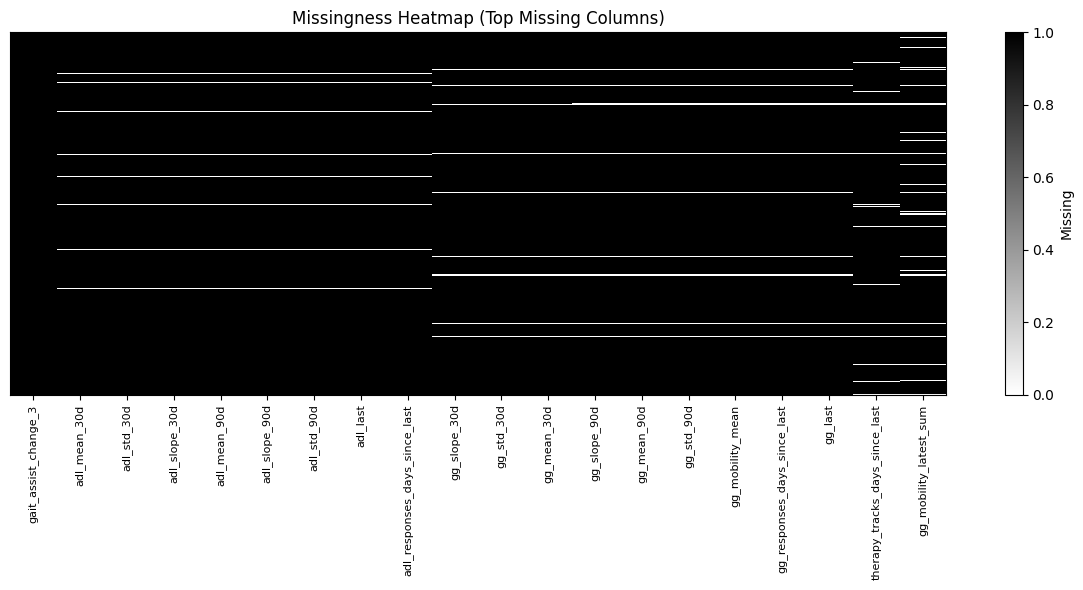

In [4]:
import matplotlib.pyplot as plt

missing_rate = df.isna().mean().sort_values(ascending=False)

top_n = 20
top_cols = missing_rate.head(top_n).index

sample_n = min(len(df), 400)

missing_sample = (
    df[top_cols]
    .isna()
    .astype(int)
    .sample(sample_n, random_state=42)
)

plt.figure(figsize=(12, 6))
plt.imshow(missing_sample.values, aspect="auto", interpolation="nearest", cmap="binary")
plt.colorbar(label="Missing")
plt.xticks(range(len(top_cols)), top_cols, rotation=90, fontsize=8)
plt.yticks([])
plt.title("Missingness Heatmap (Top Missing Columns)")
plt.tight_layout()
plt.show()

## Near-Constant / Low Variance

In [5]:
low_variance_rows = []

for col in df.columns:
    series = df[col]
    nunique = series.nunique(dropna=True)
    if pd.api.types.is_numeric_dtype(series):
        variance = series.var(skipna=True)
        if nunique <= 1 or (variance is not None and variance <= 1e-12):
            low_variance_rows.append(
                {
                    "column": col,
                    "type": "numeric",
                    "nunique": int(nunique),
                    "variance": float(variance) if pd.notna(variance) else None,
                }
            )
    else:
        if nunique <= 1:
            low_variance_rows.append(
                {
                    "column": col,
                    "type": "non_numeric",
                    "nunique": int(nunique),
                    "variance": None,
                }
            )

if low_variance_rows:
    low_variance = pd.DataFrame(low_variance_rows).sort_values(
        ["nunique", "column"], ascending=[True, True]
    )
else:
    low_variance = pd.DataFrame(
        columns=["column", "type", "nunique", "variance"]
    )

low_variance.head(30)

,column,type,nunique,variance
1,gait_assist_change_3,numeric,0,NaN
0,gait_instability_flag,numeric,1,0.0


## Per-Table Prefix Stats (FEATURE_TABLES)

In [6]:
prefix_rows = []

for prefix in FEATURE_TABLES:
    prefix_key = f"{prefix}_"
    cols = [c for c in df.columns if c.startswith(prefix_key)]
    if not cols:
        prefix_rows.append(
            {
                "table": prefix,
                "columns": 0,
                "missing_rate_mean": None,
                "zero_rate_mean": None,
            }
        )
        continue

    missing_mean = df[cols].isna().mean().mean()
    
    numeric_cols = df[cols].select_dtypes(include=["number"]).columns
    if len(numeric_cols) > 0:
        zero_mean = (df[numeric_cols] == 0).mean().mean()
    else:
        zero_mean = None

    prefix_rows.append(
        {
            "table": prefix,
            "columns": len(cols),
            "missing_rate_mean": float(missing_mean),
            "zero_rate_mean": float(zero_mean) if zero_mean is not None else None,
        }
    )

prefix_stats = pd.DataFrame(prefix_rows).sort_values(["columns", "table"], ascending=[False, True])
prefix_stats

,table,columns,missing_rate_mean,zero_rate_mean
14,vitals,83,0.387021,0.145373
0,adl_responses,4,0.243575,0.736850
2,diagnoses,4,0.055364,0.469297
3,document_tags,4,0.221926,0.675486
5,gg_responses,4,0.242015,0.733340
6,hospital_admissions,4,0.159614,0.622334
7,hospital_transfers,4,0.198458,0.680253
8,incidents,4,0.171196,0.607550
10,lab_reports,4,0.167853,0.576437
11,medications,4,0.222035,0.694015


## Label Prevalence

In [7]:
label_cols = [c for c in ["label_fall_30d", "label_rth_30d"] if c in df.columns]

label_stats = []
for col in label_cols:
    series = df[col]
    label_stats.append(
        {
            "label": col,
            "prevalence": float(series.mean()) if len(series) > 0 else None,
            "positives": int(series.sum()) if len(series) > 0 else None,
            "rows": int(len(series)),
        }
    )

pd.DataFrame(label_stats)

,label,prevalence,positives,rows
0,label_fall_30d,0.076253,4887,64089
1,label_rth_30d,0.026323,1687,64089


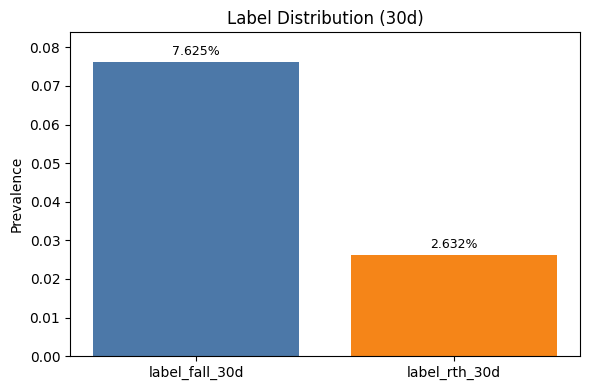

In [8]:
import matplotlib.pyplot as plt

label_cols = [c for c in ["label_fall_30d", "label_rth_30d"] if c in df.columns]
label_stats = []
for col in label_cols:
    series = df[col]
    label_stats.append(
        {
            "label": col,
            "prevalence": float(series.mean()) if len(series) > 0 else None,
            "positives": int(series.sum()) if len(series) > 0 else None,
            "rows": int(len(series)),
        }
    )

labels_df = pd.DataFrame(label_stats).sort_values("label")
plt.figure(figsize=(6, 4))
plt.bar(labels_df["label"], labels_df["prevalence"], color=["#4C78A8", "#F58518"][: len(labels_df)])
plt.ylabel("Prevalence")
plt.title("Label Distribution (30d)")
plt.ylim(0, max(labels_df["prevalence"].max() * 1.1, 0.01))
for idx, value in enumerate(labels_df["prevalence"]):
    plt.text(idx, value + 0.001, f"{value:.3%}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

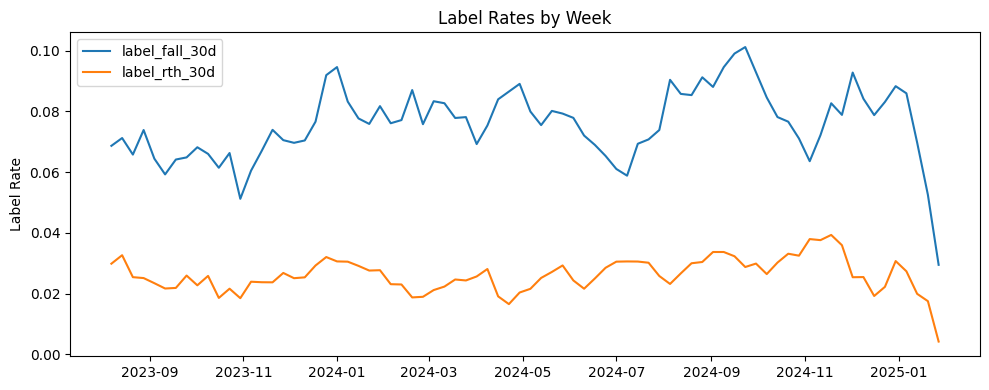

In [9]:
import matplotlib.pyplot as plt

label_cols = [c for c in ["label_fall_30d", "label_rth_30d"] if c in df.columns]
if not label_cols:
    raise ValueError("No label columns found in dataset.")

date_cols = [
    c
    for c in df.columns
    if any(key in c for key in ["snapshot", "reference", "as_of", "week", "date", "dt", "time"])
]
date_col = next(
    (c for c in date_cols if pd.api.types.is_datetime64_any_dtype(df[c])),
None
)
if date_col is None:
    for c in date_cols:
        parsed = pd.to_datetime(df[c], errors="coerce")
        if parsed.notna().mean() >= 0.9:
            date_col = c
            break
if date_col is None:
    raise ValueError("No snapshot date column found for weekly label rates.")

weekly = df[[date_col] + label_cols].copy()
weekly[date_col] = pd.to_datetime(weekly[date_col], errors="coerce")
weekly = weekly.dropna(subset=[date_col])
weekly["week"] = weekly[date_col].dt.to_period("W").apply(lambda p: p.start_time)
rate_df = weekly.groupby("week")[label_cols].mean().sort_index()

plt.figure(figsize=(10, 4))
for col in label_cols:
    plt.plot(rate_df.index, rate_df[col], label=col)
plt.ylabel("Label Rate")
plt.title("Label Rates by Week")
plt.legend()
plt.tight_layout()
plt.show()

## Flagged Candidates

In [10]:
flags = []

missing_rate = df.isna().mean()
numeric_cols = df.select_dtypes(include=["number"]).columns
zero_rate = pd.Series(0.0, index=df.columns)
zero_rate.loc[numeric_cols] = (df[numeric_cols] == 0).mean()

for col in df.columns:
    series = df[col]
    nunique = series.nunique(dropna=True)
    variance = series.var(skipna=True) if pd.api.types.is_numeric_dtype(series) else None

    reasons = []
    if missing_rate[col] >= 0.9:
        reasons.append("missing>=0.90")
    if col in numeric_cols and zero_rate[col] >= 0.95:
        reasons.append("zero>=0.95")
    if nunique <= 1:
        reasons.append("nunique<=1")
    if variance is not None and variance <= 1e-12:
        reasons.append("variance<=1e-12")

    if reasons:
        flags.append(
            {
                "column": col,
                "missing_rate": float(missing_rate[col]),
                "zero_rate": float(zero_rate[col]) if col in numeric_cols else None,
                "nunique": int(nunique),
                "variance": float(variance) if variance is not None else None,
                "reasons": ";".join(reasons),
            }
        )

flagged = pd.DataFrame(flags).sort_values(
    ["missing_rate", "zero_rate", "nunique", "column"], ascending=[False, False, True, True]
)
flagged.head(50)

,column,missing_rate,zero_rate,nunique,variance,reasons
45,gait_assist_change_3,1.000000,0.000000,0,NaN,missing>=0.90;nunique<=1
19,adl_slope_30d,0.975440,0.010017,115,0.034783,missing>=0.90
17,adl_mean_30d,0.975440,0.000047,1537,0.957584,missing>=0.90
18,adl_std_30d,0.975440,0.000047,1564,0.128148,missing>=0.90
23,adl_slope_90d,0.974816,0.009783,276,0.032358,missing>=0.90
21,adl_mean_90d,0.974816,0.000000,1595,0.940657,missing>=0.90
22,adl_std_90d,0.974816,0.000000,1603,0.120936,missing>=0.90
3,adl_responses_days_since_last,0.974301,0.022843,26,339.458723,missing>=0.90
16,adl_last,0.974301,0.008738,6,2.237882,missing>=0.90
28,gg_slope_30d,0.969183,0.011125,190,0.293645,missing>=0.90


## Modeling Feature Set Decision

We will drop features manually based on the flagged table, while always keeping id/date columns and labels. The selected feature list below is the modeling input and is saved to `outputs/selected_features.csv`.

In [11]:
from pathlib import Path

label_cols = [c for c in ["label_fall_30d", "label_rth_30d"] if c in df.columns]
id_cols = [
    c
    for c in df.columns
    if c in ["resident_id", "facility_id", "patient_id", "person_id"]
 ]
date_like_cols = [
    c
    for c in df.columns
    if any(key in c.lower() for key in ["date", "dt", "time", "timestamp", "snapshot", "as_of", "week", "reference"])
]
protected_cols = set(label_cols + id_cols + date_like_cols)

# Fill these lists from the flagged table above.
manual_drop_cols = [
    # "example_feature_col",
]
manual_drop_prefixes = [
    # "lab_reports_",
]

feature_cols = [c for c in df.columns if c not in protected_cols]
drop_set = set(manual_drop_cols)
for prefix in manual_drop_prefixes:
    drop_set.update([c for c in feature_cols if c.startswith(prefix)])

selected_features = [c for c in feature_cols if c not in drop_set]

selected_features_path = root / "outputs" / "selected_features.csv"
pd.Series(selected_features, name="feature").to_csv(selected_features_path, index=False)

summary_rows = []
for prefix in FEATURE_TABLES:
    prefix_key = f"{prefix}_"
    kept = [c for c in selected_features if c.startswith(prefix_key)]
    summary_rows.append({"table": prefix, "kept_features": len(kept)})

summary = pd.DataFrame(summary_rows).sort_values(["kept_features", "table"], ascending=[False, True])
print(f"Selected features: {len(selected_features)}")
print(f"Protected columns (id/date/labels): {len(protected_cols)}")
summary

Selected features: 199
Protected columns (id/date/labels): 5


,table,kept_features
14,vitals,83
0,adl_responses,4
2,diagnoses,4
3,document_tags,4
5,gg_responses,4
6,hospital_admissions,4
7,hospital_transfers,4
8,incidents,4
10,lab_reports,4
11,medications,4


In [12]:
from sklearn.feature_selection import mutual_info_classif

label_cols = [c for c in ["label_fall_30d", "label_rth_30d"] if c in df.columns]
if not label_cols:
    raise ValueError("No label columns found.")

id_cols = [c for c in df.columns if c in ["resident_id", "facility_id", "patient_id", "person_id"]]
date_like_cols = [c for c in df.columns if any(k in c.lower() for k in ["date", "dt", "time", "snapshot", "as_of", "week", "reference"])]
protected_cols = set(label_cols + id_cols + date_like_cols)

numeric_cols = [c for c in df.select_dtypes(include=["number"]).columns if c not in protected_cols]
X = df[numeric_cols].copy()
X = X.loc[:, X.isna().mean() <= 0.95]
X = X.fillna(0)

rows = []
for label in label_cols:
    y = df[label].astype(int)
    if y.nunique() < 2:
        continue
    mi = mutual_info_classif(X, y, discrete_features=False, random_state=42)
    mi_series = pd.Series(mi, index=X.columns)
    rows.append(mi_series.rename(label))

mi_df = pd.concat(rows, axis=1) if rows else pd.DataFrame(index=X.columns)
mi_df["mi_mean"] = mi_df.mean(axis=1) if not mi_df.empty else 0.0

feature_stats = pd.DataFrame({
    "feature": mi_df.index,
    "mi_mean": mi_df["mi_mean"].values,
    "missing_rate": df[mi_df.index].isna().mean().values,
    "variance": df[mi_df.index].var(skipna=True).values,
})
feature_stats = feature_stats.sort_values(["mi_mean", "missing_rate"], ascending=[True, False])

low_signal = feature_stats.head(50)
print("Lowest signal features (by mean MI):")
low_signal

Lowest signal features (by mean MI):


,feature,mi_mean,missing_rate,variance
101,vitals_pain_level_min_30d,0.000000,0.384356,0.124407
105,vitals_pain_level_min_90d,0.000000,0.357909,0.102614
39,therapy_tracks_count_30d,0.000000,0.000000,0.063486
128,vitals_respiration_abnormal_30d,0.000000,0.000000,0.016583
166,polypharmacy_30d_flag,0.000000,0.000000,0.081453
31,medications_count_30d,0.000041,0.000000,51029.972331
164,gg_mobility_latest_sum,0.000046,0.927523,211.107453
171,bp_systolic_variance_flag,0.000077,0.000000,0.004767
177,pt_active_flag,0.000110,0.000000,0.017968
50,los_91_180,0.000127,0.000000,0.093935


In [13]:
high_signal = feature_stats.sort_values("mi_mean", ascending=False).head(20)
print("Top signal features (by mean MI):")
high_signal

Top signal features (by mean MI):


,feature,mi_mean,missing_rate,variance
144,vitals_weight_mean_90d,0.046149,0.291423,4641.458208
146,vitals_weight_max_90d,0.045305,0.291423,122327.858608
145,vitals_weight_min_90d,0.039533,0.291423,3341.434202
147,vitals_weight_std_90d,0.031863,0.291423,10708.696915
139,vitals_weight_last,0.031148,0.276491,6587.852626
148,last_weight,0.030732,0.276491,6587.852626
141,vitals_weight_min_30d,0.027850,0.361045,3288.465759
142,vitals_weight_max_30d,0.027043,0.361045,57240.954532
140,vitals_weight_mean_30d,0.025345,0.361045,6398.029203
137,vitals_temperature_std_90d,0.023814,0.389209,3117.410443


In [ ]:
top_n = 100
top_features = {}

for label in label_cols:
    if label not in mi_df.columns:
        continue
    top_list = (
        mi_df[label]
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )
    top_features[label] = top_list
    out_path = root / "outputs" / f"selected_features_top100_{label}.csv"
    pd.Series(top_list, name="feature").to_csv(out_path, index=False)
    print(f"Saved {len(top_list)} features to {out_path}")

if len(top_features) >= 2:
    labels = list(top_features.keys())
    left = set(top_features[labels[0]])
    right = set(top_features[labels[1]])
    overlap = sorted(left & right)
    print(f"Overlap count ({labels[0]} vs {labels[1]}): {len(overlap)}")
    print("Overlap sample:", overlap[:20])